# PERPL analysis for ACTN2

# IMPORTANT
# Disable autosave for Jupytext version control with a paired .py script
# But manually saving the notebook frequently is still good

In [148]:
%autosave 0

Autosave disabled


## Imports

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from perpl.modelling import modelling_general, zdisk_modelling, zdisk_plots
from perpl.io import plotting

## Variables which we will read in using argparse

In [168]:
actn_affimer_relpos_path = r"/home/oliver/smlm_cloud/janelia_analysis/experiments/ACTN2/output/perpl_relative_posns/all_z_disks_15.0precisionfilter_PERPL-relpos_150.0filter.csv" # path to relative posn data
fitlength = 100. # standard max distance over which to plot distances and fit models
loc_prec_path = r"/home/oliver/smlm_cloud/janelia_analysis/experiments/ACTN2/output/perpl_relative_posns/all_z_disks_15.0precisionfilter_PERPL-locprec_150.0filter.txt"
transverse_limit = 10. # This is the YZ-distance limit for X-distances to include

## Load in average estimated localisation precision
This is the mean after filtering for localisation precision

In [169]:
loc_precision = np.loadtxt(loc_prec_path) # Mean value after filtering for precision < 5 nm

## Load in relative position data

In [170]:
relpos = pd.read_csv(actn_affimer_relpos_path)

### Data attributes and number of data points:

In [171]:
relpos.iloc[0, :] # This shows the first relative position.

xx_separation     0.137814
yy_separation     2.825068
zz_separation     1.213900
xy_separation     2.828427
xz_separation     1.221698
yz_separation     3.074827
xyz_separation    3.077914
Name: 0, dtype: float64

In [172]:
len(relpos) # This shows how many relative positions.

2496056

## Convert relpos 

Note for AC. axial direction is X... but here axial direction is y
Transverse direction is xz

In [173]:
relpos = pd.DataFrame({
    "axial": relpos.yy_separation,
    "transverse": relpos.xz_separation},)

## Get the axial (Y) distances, without duplicates
The XZ-distance limit for pairs of localisations to include can be set here.

In [174]:
axial_distances = zdisk_modelling.getaxialseparations_no_smoothing(
    relpos,
    max_distance=relpos.axial.max(),
    transverse_limit=transverse_limit
    )
axial_distances = zdisk_modelling.remove_duplicates(axial_distances)

## Get the 1-nm bin histogram data
Up to distance = fitlength

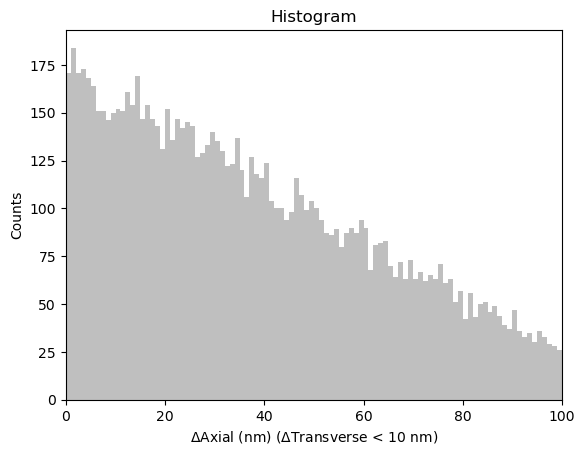

In [175]:
hist_values, bin_edges = zdisk_plots.plot_distance_hist(
    axial_distances,
    fitlength
    )
bin_centres = (bin_edges[0:(len(bin_edges) - 1)]
            + bin_edges[1:]
            ) / 2

## Get the KDE data
Estimate every 1 nm, with kernel size based on localisation precision estimate.

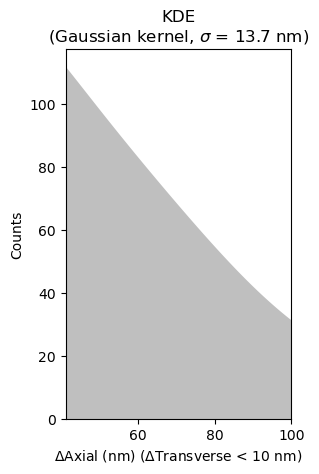

In [176]:
kde_x_values, kde = zdisk_plots.plot_distance_kde(
    axial_distances,
    loc_precision,
    100.
    )

## Calculate the axial RPD with smoothing for Churchman 1D function

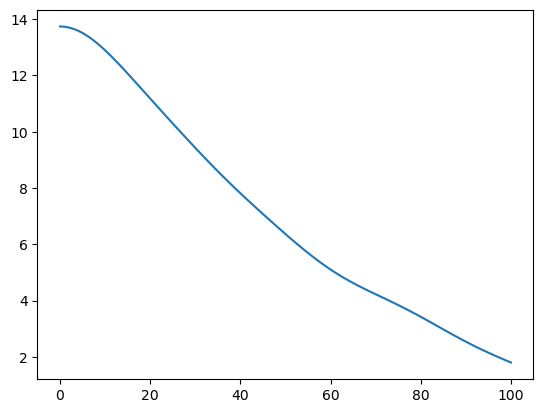

In [144]:
calculation_points = np.arange(fitlength + 1.)
axial_rpd = plotting.estimate_rpd_churchman_1d(
    input_distances=axial_distances,
    calculation_points=calculation_points,
    combined_precision=(np.sqrt(2) * loc_precision)
)
plt.plot(calculation_points, axial_rpd)

## Choose axial model:

In [112]:
axial_model_with_info = zdisk_modelling.set_up_model_4_peaks_fixed_ratio_with_fit_settings()

## Fit model to histogram bin values, at bin centres

In [113]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    bin_centres,
    hist_values,
    axial_model_with_info.model_rpd,
    axial_model_with_info.initial_params,
    axial_model_with_info.param_bounds,
    )
print('')
print('Initial parameter guesses:')
print(axial_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(axial_model_with_info.param_bounds)

[[ 9.63726360e+00  1.79807372e+01]
 [ 1.16755958e+01  1.13096449e+02]
 [ 1.00000000e+03  7.63268137e+04]
 [ 1.35837345e+01  9.50683094e+02]
 [ 1.00000000e+03  1.95394322e+05]
 [-8.21429171e-02  1.22164408e+00]
 [ 1.00000000e+02  1.09769595e+02]]
SSR = 128481.76993304939
AIC = 731.8372119039775
AICcorr = 733.4196294863951

Initial parameter guesses:
[20, 5, 1, 3, 1, -0.2, 20]

Parameter bounds:
([0, 0, 0, 0, 0, -100, 0], [50, 20, 1000, 20, 1000, 100, 100])


## Plot fitted model over histogram data

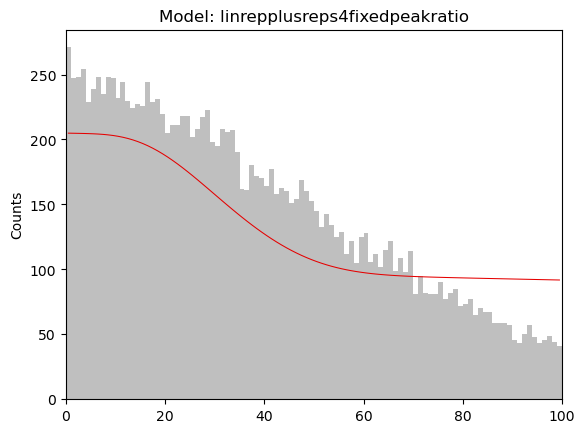

In [114]:
fig, axes = zdisk_plots.plot_distance_hist_and_fit(
    axial_distances,
    fitlength,
    params_optimised,
    params_covar,
    axial_model_with_info
)

## Plot fitted model over histogram data, with confidence intervals on the model
### NOTE: IT TAKES A WHILE TO CALCULATE THE CONFIDENCE INTERVALS
### Skip this if you don't need it right now.

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Model: linrepplusreps4fixedpeakratio'}, ylabel='Counts'>)

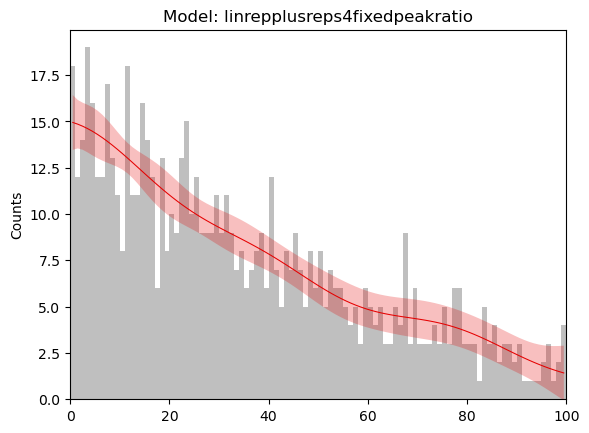

In [79]:
zdisk_plots.plot_distance_hist_and_fit(
    axial_distances,
    fitlength,
    params_optimised,
    params_covar,
    axial_model_with_info,
    plot_95ci=True
)

## Akaike weights for the models
Typed in AICc values for the different models here, to obtain relative likelihood, summing to one:

In [22]:
from perpl.statistics.modelstats import akaike_weights
weights = akaike_weights([
    364.35,
    364.51,
    366.38,
    370.28,
    374.67
])
print(weights)

[0.42683586 0.39401916 0.15468635 0.02200786 0.00245076]


## Plot model components for best model (4 peaks with fixed peak ratio)

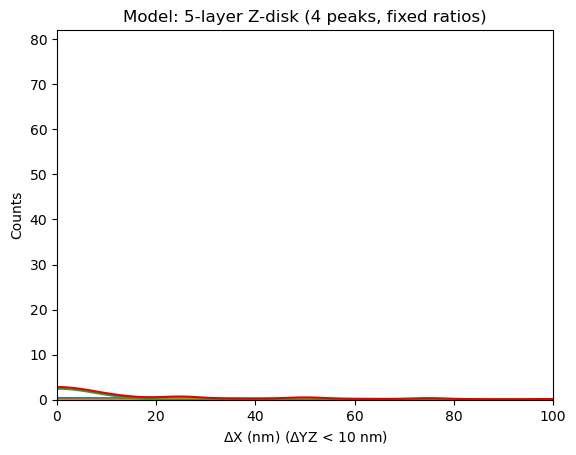

In [23]:
zdisk_plots.plot_model_components_4peaks_fixed_peak_ratio(
    fitlength,
    *params_optimised)

# Transverse distances

## Get the transverse (YZ) distances, without duplicates
The X-distance limit for pairs of localisations to include can be set here.

In [24]:
# This is the YZ-distance limit for X-distances to include:
axial_limit = 10.
print(relpos.shape)

trans_distances = zdisk_modelling.get_transverse_separations(
    relpos,
    max_distance=relpos.transverse.max(),
    axial_limit=axial_limit
    )
trans_distances = zdisk_modelling.remove_duplicates(trans_distances)

(3488, 2)


## Choose analysis lengthscale for transverse distance

In [25]:
fitlength = 50.

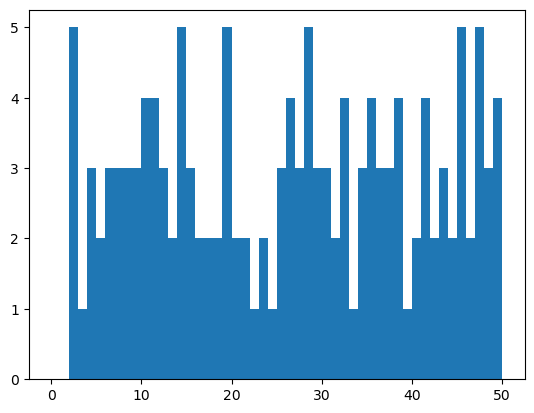

In [26]:
hist_1nm_bins = plt.hist(trans_distances, bins=np.arange(fitlength + 1.))

## Estimate RPD using Churchman's function

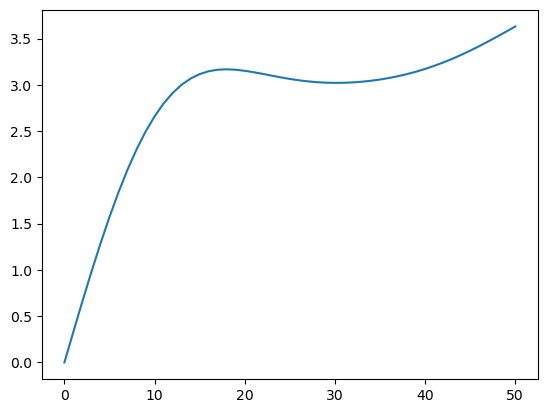

In [27]:
fitlength = 50.
calculation_points = np.arange(fitlength + 1.)
combined_precision= np.sqrt(2) * loc_precision
transverse_rpd = plotting.estimate_rpd_churchman_2d(
    input_distances=trans_distances[trans_distances < (fitlength + 3 * combined_precision)],
    calculation_points=calculation_points,
    combined_precision=combined_precision
)
plt.plot(calculation_points, transverse_rpd)

## Normalise for increasing search circle with increasing distance

In [ ]:
normalised_transverse_rpd = transverse_rpd[calculation_points > 0.] / calculation_points[calculation_points > 0.]
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]
plt.plot(norm_rpd_calculation_points, normalised_transverse_rpd)

### 1 nm-bin  histogram result for comparison

In [ ]:
plt.plot(hist_1nm_bins[1][0:-1] + 0.5, hist_1nm_bins[0]/(hist_1nm_bins[1][0:-1] + 0.5))

### Optional save/load to save time

In [ ]:
np.save('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-4p4', normalised_transverse_rpd)
# normalised_transverse_rpd = np.load('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-4p4.npy')

## Set up an RPD model and fit
I've tried a few smoothing kernel widths here.

In [ ]:
trans_model_with_info = zdisk_modelling.set_up_model_2d_onepeak_plus_replocs_flat_bg_with_fit_settings()

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points,
    normalised_transverse_rpd)
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points,
    fitlength,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=False
    )

In [ ]:
fitlength = 50.
calculation_points = np.arange(fitlength + 1.)
combined_precision=8.
transverse_rpd_s8 = plotting.estimate_rpd_churchman_2d(
    input_distances=trans_distances[trans_distances < (fitlength + 3 * combined_precision)],
    calculation_points=calculation_points,
    combined_precision=combined_precision
)

In [ ]:
normalised_transverse_rpd_s8 = transverse_rpd_s8[calculation_points > 0.] / calculation_points[calculation_points > 0.]
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]
plt.plot(norm_rpd_calculation_points, normalised_transverse_rpd_s8)
np.save('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-8', normalised_transverse_rpd_s8)
# normalised_transverse_rpd = np.load('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-8.npy')

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s8[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points,
    normalised_transverse_rpd_s8)
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points,
    fitlength,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=False
    )

In [ ]:
fitlength = 50.
calculation_points = np.arange(fitlength + 1.)
combined_precision=5.
transverse_rpd_s5 = plotting.estimate_rpd_churchman_2d(
    input_distances=trans_distances[trans_distances < (fitlength + 3 * combined_precision)],
    calculation_points=calculation_points,
    combined_precision=combined_precision
)

In [ ]:
normalised_transverse_rpd_s5 = transverse_rpd_s5[calculation_points > 0.] / calculation_points[calculation_points > 0.]
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]
plt.plot(norm_rpd_calculation_points, normalised_transverse_rpd_s5)
np.save('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-5', normalised_transverse_rpd_s5)

In [ ]:
fitlength = 50.
calculation_points = np.arange(fitlength + 1.)
combined_precision=6.
transverse_rpd_s6 = plotting.estimate_rpd_churchman_2d(
    input_distances=trans_distances[trans_distances < (fitlength + 3 * combined_precision)],
    calculation_points=calculation_points,
    combined_precision=combined_precision
)

In [ ]:
normalised_transverse_rpd_s6 = transverse_rpd_s6[calculation_points > 0.] / calculation_points[calculation_points > 0.]
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]
plt.plot(norm_rpd_calculation_points, normalised_transverse_rpd_s6)
np.save('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-6', normalised_transverse_rpd_s6)

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s6[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points,
    normalised_transverse_rpd_s8)
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points,
    fitlength,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=False
    )

## Set up another model and fit
Tried a few smoothing widths again
### This model fits much better

In [ ]:
trans_model_with_info = zdisk_modelling.set_up_model_2d_twopeaks_flat_bg_with_fit_settings()

In [ ]:
normalised_transverse_rpd_s6 = np.load('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-6.npy')
calculation_points = np.arange(fitlength + 1.)
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s6[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s6[0:31])
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points[0:31],
    31.,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=True
    )

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd[0:31])
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points[0:31],
    31.,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=True
    )

In [ ]:
normalised_transverse_rpd_s8 = np.load('..//..//perpl_test_data//normalised_transverse_rpd_smoothed_Churchman-8.npy')
calculation_points = np.arange(fitlength + 1.)
norm_rpd_calculation_points = calculation_points[calculation_points > 0.]

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s8[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s8[0:31])
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points[0:31],
    31.,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=True
    )

In [ ]:
(params_optimised,
params_covar,
params_1sd_error) = zdisk_modelling.fitmodel_to_hist(
    norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s5[0:31],
    trans_model_with_info.model_rpd,
    trans_model_with_info.initial_params,
    trans_model_with_info.param_bounds
    )
print('')
print('Initial parameter guesses:')
print(trans_model_with_info.initial_params)
print('')
print('Parameter bounds:')
print(trans_model_with_info.param_bounds)

In [ ]:
plt.plot(norm_rpd_calculation_points[0:31],
    normalised_transverse_rpd_s5[0:31])
zdisk_plots.plot_fitted_model(
    norm_rpd_calculation_points[0:31],
    31.,
    params_optimised,
    params_covar,
    trans_model_with_info,
    plot_95ci=True
    )